In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download required NLP data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
# Load the two CSV files
df1 = pd.read_csv('fake_job_postings.csv')
df2 = pd.read_csv('Fake Postings.csv')

# 1. Define all the features you want to include
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
meta_cols = ['location', 'salary_range', 'employment_type', 'industry', 'required_experience']
target_col = 'fraudulent'

# All desired columns
all_cols = text_cols + meta_cols + [target_col]

# 2. Function to safely extract columns
def safe_extract(df, columns):
    # If a column is missing, create it with 'Unspecified'
    for col in columns:
        if col not in df.columns:
            df[col] = 'Unspecified'
    return df[columns].fillna('Unspecified')

# Extract and clean both subsets safely
df1_subset = safe_extract(df1, all_cols)
df2_subset = safe_extract(df2, all_cols)

# 3. Combine into one master dataframe
df = pd.concat([df1_subset, df2_subset], axis=0).reset_index(drop=True)

# 4. Create the "Super Feature"
# Combine all text and metadata into one large string for TF-IDF
df['combined_text'] = df[text_cols + meta_cols].apply(lambda row: ' '.join(row.values.astype(str)), axis=1)

print(f"Dataset merged successfully. Total records: {len(df)}")
print("Common columns now present in merged data:", df.columns.tolist())

Dataset merged successfully. Total records: 27880
Common columns now present in merged data: ['title', 'company_profile', 'description', 'requirements', 'benefits', 'location', 'salary_range', 'employment_type', 'industry', 'required_experience', 'fraudulent', 'combined_text']


In [5]:
# Import tools if not already imported in earlier cells
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_with_numbers(text):
    # 1. Keep both letters (a-z) and numbers (0-9)
    text = re.sub(r'[^a-zA-Z0-9]', ' ', str(text)).lower()
    
    # 2. Tokenize and remove stopwords/lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

# Apply to the merged dataframe 'df'
print("Cleaning text (preserving numbers)... This may take a minute.")
df['clean_text'] = df['combined_text'].apply(clean_text_with_numbers)

print("Text cleaning completed.")
print("Sample of cleaned text with numbers:")
print(df['clean_text'].iloc[0][:150])

Cleaning text (preserving numbers)... This may take a minute.
Text cleaning completed.
Sample of cleaned text with numbers:
marketing intern food52 created groundbreaking award winning cooking site support connect celebrate home cook give everything need one place top edito


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# We use 5,000 features to keep the model efficient but accurate
tfidf = TfidfVectorizer(max_features=5000)

print("Vectorizing text data...")
X = tfidf.fit_transform(df['clean_text'])
y = df['fraudulent']

print(f"Feature matrix created with shape: {X.shape}")

Vectorizing text data...
Feature matrix created with shape: (27880, 5000)


In [7]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. First: Split the original data (X, y) into 80% Train and 20% Test
# We use 'raw' in the name so we know this data isn't balanced yet
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Second: Apply SMOTE only to the TRAINING portion
print("Applying SMOTE to the training set...")
smote = SMOTE(random_state=42)

# This creates the final X_train and y_train that your model will use
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f"--- Process Complete ---")
print(f"1. Original Train Size: {X_train_raw.shape[0]}")
print(f"2. SMOTE Balanced Train Size: {X_train.shape[0]}")
print(f"3. Pure Test Set Size: {X_test.shape[0]}")

Applying SMOTE to the training set...
--- Process Complete ---
1. Original Train Size: 22304
2. SMOTE Balanced Train Size: 27222
3. Pure Test Set Size: 5576


In [8]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [9]:
# Create a list of tuples: (name, model_instance)
base_models = [
    # SVM: Uses geometric margins. We set probability=True to get a 0-1 score.
    ('svm', SVC(kernel='linear', probability=True, random_state=42)),
    
    # Naive Bayes: Uses word frequency probability.
    ('nb', MultinomialNB()),
    
    # Logistic Regression (Base): A standard linear approach.
    ('lr_base', LogisticRegression(max_iter=1000, random_state=42))
]

In [10]:
# We use Logistic Regression as the 'Final Referee'
meta_learner = LogisticRegression()

In [11]:
# Initialize the Stacking Classifier
stacking_model = StackingClassifier(
    estimators=base_models,      # The list of Level-0 experts
    final_estimator=meta_learner, # The Level-1 manager
    cv=5                          # Uses 5-fold cross-validation to train the meta-learner
)

print("Training Hybrid Stacking Model... (This may take a few minutes)")

# Fit the model on the training data (TF-IDF features and Fraud labels)
stacking_model.fit(X_train, y_train)

print("Model training completed successfully.")

Training Hybrid Stacking Model... (This may take a few minutes)
Model training completed successfully.


HYBRID STACKING SYSTEM: FINAL RESULTS
Overall Accuracy: 0.9909

Detailed Performance Report:
              precision    recall  f1-score   support

    Real (0)       0.99      1.00      0.99      3403
    Fake (1)       0.99      0.98      0.99      2173

    accuracy                           0.99      5576
   macro avg       0.99      0.99      0.99      5576
weighted avg       0.99      0.99      0.99      5576



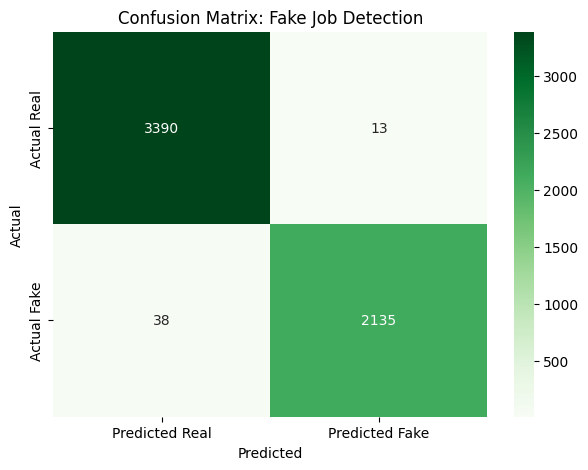

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Predict labels for the original test set
y_pred = stacking_model.predict(X_test)

# 2. Print summary metrics
print("="*40)
print("HYBRID STACKING SYSTEM: FINAL RESULTS")
print("="*40)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 3. Detailed report for each class (Real vs. Fake)
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['Real (0)', 'Fake (1)']))

# 4. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Real', 'Predicted Fake'], 
            yticklabels=['Actual Real', 'Actual Fake'])
plt.title('Confusion Matrix: Fake Job Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("Starting 5-Fold Cross-Validation... (This will take a moment)")

# We use the balanced X_train and y_train
# cv=5 means the data is split into 5 parts, and the model is trained 5 times
cv_scores = cross_val_score(stacking_model, X_train, y_train, cv=5, scoring='accuracy')

print("-" * 30)
print(f"Individual Fold Accuracies: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores)*100:.2f}%")
print(f"Standard Deviation: {np.std(cv_scores)*100:.2f}%")
print("-" * 30)

Starting 5-Fold Cross-Validation... (This will take a moment)
------------------------------
Individual Fold Accuracies: [0.98696051 0.98714417 0.98806025 0.99283615 0.99228508]
Mean CV Accuracy: 98.95%
Standard Deviation: 0.26%
------------------------------


In [15]:
# 1. Final Training of the Stacking Model
# This uses the full X_train and y_train (SMOTE-balanced)
print("Finalizing the Hybrid Stacking Model... Please wait.")

stacking_model.fit(X_train, y_train)

print("="*40)
print("FINAL MODEL TRAINING COMPLETE")
print("="*40)
print("The model is now fully optimized and ready for deployment.")

Finalizing the Hybrid Stacking Model... Please wait.
FINAL MODEL TRAINING COMPLETE
The model is now fully optimized and ready for deployment.


In [16]:
import joblib

# 1. Save the trained Stacking Model
joblib.dump(stacking_model, 'job_fraud_stacking_model.pkl')

# 2. Save the TF-IDF Vectorizer 
# (The model cannot understand text without this specific vectorizer)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("="*40)
print("SUCCESS: Model and Vectorizer saved to disk!")
print("Files: job_fraud_stacking_model.pkl, tfidf_vectorizer.pkl")
print("="*40)

SUCCESS: Model and Vectorizer saved to disk!
Files: job_fraud_stacking_model.pkl, tfidf_vectorizer.pkl


In [17]:
def check_job_scam(ad_text):
    # 1. Clean the input text using your Step 3 logic
    cleaned = clean_text_with_numbers(ad_text)
    
    # 2. Convert text to TF-IDF features
    vectorized = tfidf.transform([cleaned])
    
    # 3. Get Prediction and Probability from the Stacking Model
    prediction = stacking_model.predict(vectorized)[0]
    probs = stacking_model.predict_proba(vectorized)[0]
    
    # 4. Format the result
    is_fake = (prediction == 1)
    status = "🚩 SCAM / FRAUDULENT" if is_fake else "✅ REAL / LEGITIMATE"
    confidence = probs[1] if is_fake else probs[0]
    
    print("\n" + "!"*45)
    print("      HYBRID STACKING PREDICTION SYSTEM      ")
    print("!"*45)
    print(f"Final Decision: {status}")
    print(f"Confidence:     {confidence*100:.2f}%")
    print("-" * 45)
    
    if is_fake:
        print("Insight: The meta-learner detected linguistic patterns\nand metadata clusters associated with job fraud.")
    else:
        print("Insight: This ad aligns with the statistical profile\nof legitimate professional hiring.")
    print("!"*45 + "\n")

# Activate the system
print("Prediction System is now LIVE. Use check_job_scam(text) to test.")


Prediction System is now LIVE. Use check_job_scam(text) to test.


In [18]:
test_real = """
Senior Data Engineer - Amazon. 
Work with AWS, Redshift, and Spark. 
Minimum 5 years experience required. 
Full benefits, 401k, and competitive salary. 
Apply through our official Amazon Jobs portal.
"""
check_job_scam(test_real)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
      HYBRID STACKING PREDICTION SYSTEM      
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Final Decision: ✅ REAL / LEGITIMATE
Confidence:     97.16%
---------------------------------------------
Insight: This ad aligns with the statistical profile
of legitimate professional hiring.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



In [19]:
test_scam = """
URGENT: Work from home as a Personal Assistant. 
$4000 monthly. No experience needed. 
We will send you a check for equipment. 
Contact us via WhatsApp at +1-555-0192.
"""
check_job_scam(test_scam)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
      HYBRID STACKING PREDICTION SYSTEM      
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Final Decision: 🚩 SCAM / FRAUDULENT
Confidence:     96.42%
---------------------------------------------
Insight: The meta-learner detected linguistic patterns
and metadata clusters associated with job fraud.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



In [20]:
# Testing random, meaningless characters
gibberish_text = "geghjyguwehyufuygyawftGiahufyha yreutgu eurutyghe rgfhevwug gwioajnzv nyedhgerdi e4ifoihvauy gdfbsujs"

check_job_scam(gibberish_text)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
      HYBRID STACKING PREDICTION SYSTEM      
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Final Decision: ✅ REAL / LEGITIMATE
Confidence:     95.64%
---------------------------------------------
Insight: This ad aligns with the statistical profile
of legitimate professional hiring.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



In [21]:
# The text from the advertisement you provided
new_test_ad = """
📢 We’re Hiring: Talent Acquisition Trainee 📢

Looking to kickstart your career in recruitment and HR? Join our team as a Talent Acquisition Trainee and gain hands-on experience in end-to-end hiring processes!

📍 Location: Noida, Sector 63 (Work from Office)
⏰ Working Hours: 9:30 AM – 6:30 PM
📅 Work Schedule: 6 days a week (3rd Saturday off)

💼 What You’ll Do:
Assist in sourcing and screening candidates
Schedule and coordinate interviews
Work closely with hiring managers
Manage candidate databases and job postings

🎓 Who Can Apply:
Freshers (Graduates) or candidates interested in HR/Recruitment
Strong communication and interpersonal skills
Eagerness to learn and grow in Talent Acquisition
✨ Great opportunity to build your career in HR with real-time exposure and a supportive team environment!

📥 Interested candidates can send their CV via DM.
📲 For a quick response, kindly share your details via WhatsApp only to 
Anjali – 9218464596
"""

# Running the detection function
check_job_scam(new_test_ad)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
      HYBRID STACKING PREDICTION SYSTEM      
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Final Decision: ✅ REAL / LEGITIMATE
Confidence:     98.99%
---------------------------------------------
Insight: This ad aligns with the statistical profile
of legitimate professional hiring.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



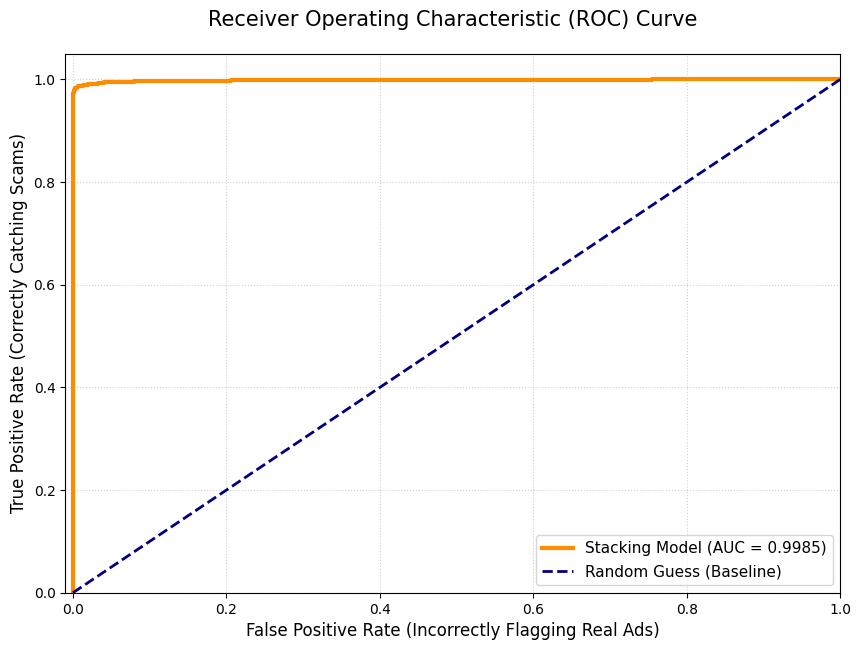

MODEL PERFORMANCE METRICS
AUC Score: 0.9985
Performance Category: Excellent


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calculate probabilities for the 'Fake' (1) class
# This tells us how certain the model is (e.g., 0.99 for Fake)
y_probs = stacking_model.predict_proba(X_test)[:, 1]

# 2. Get the False Positive Rate and True Positive Rate
fpr, tpr, _ = roc_curve(y_test, y_probs)

# 3. Calculate the Area Under the Curve (AUC)
auc_score = roc_auc_score(y_test, y_probs)

# 4. Create the Plot
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='#FF8C00', lw=3, label=f'Stacking Model (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='#000080', lw=2, linestyle='--', label='Random Guess (Baseline)')

# Styling the Graph
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, pad=20)
plt.xlabel('False Positive Rate (Incorrectly Flagging Real Ads)', fontsize=12)
plt.ylabel('True Positive Rate (Correctly Catching Scams)', fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])

plt.show()

# 5. Printed Summary for your Record
print(f"{'='*30}")
print(f"MODEL PERFORMANCE METRICS")
print(f"{'='*30}")
print(f"AUC Score: {auc_score:.4f}")
print(f"Performance Category: {'Excellent' if auc_score > 0.9 else 'Good'}")
print(f"{'='*30}")

✅ Stacking Model loaded successfully!


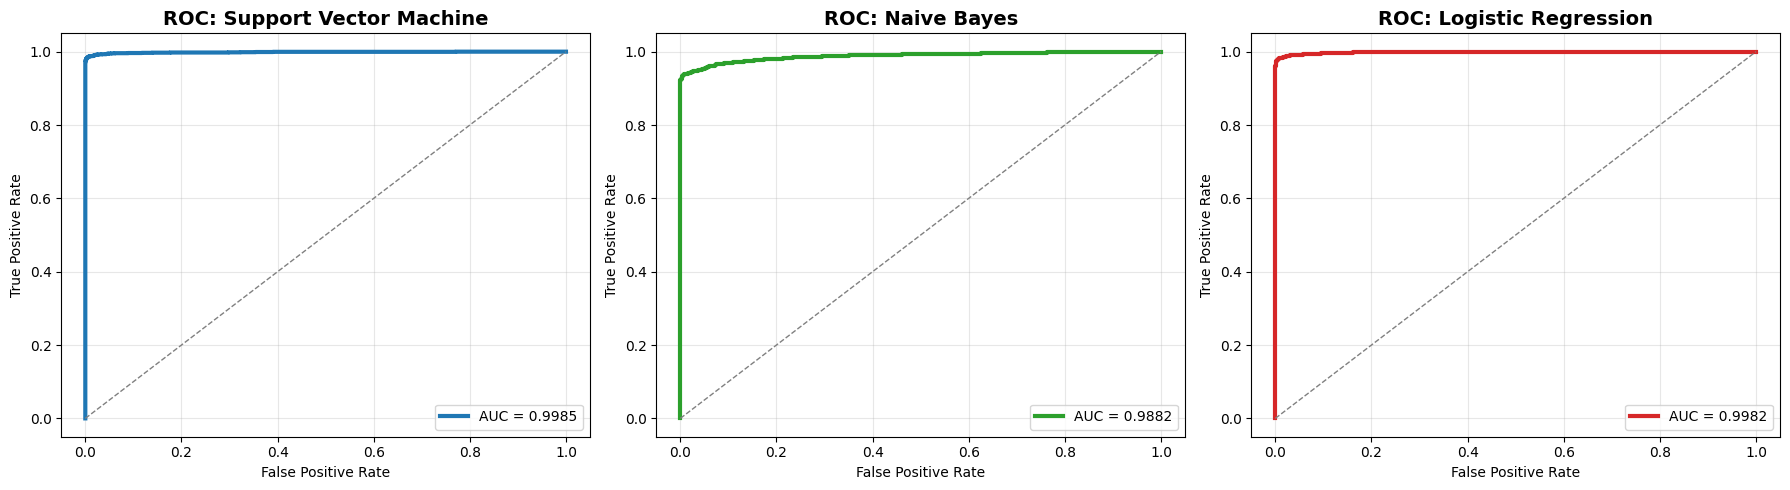

In [23]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Load using your EXACT file names from the image
try:
    stacking_model = joblib.load('job_fraud_stacking_model.pkl')
    print("✅ Stacking Model loaded successfully!")
except FileNotFoundError:
    print("❌ Error: 'job_fraud_stacking_model.pkl' not found in this folder.")

# 2. Setup for 3 separate graphs
# These keys 'svm', 'nb', 'lr_base' are internal to your stacking model
sub_models = {
    'Support Vector Machine': ('svm', '#1f77b4'), 
    'Naive Bayes': ('nb', '#2ca02c'),             
    'Logistic Regression': ('lr_base', '#d62728')  
}

# Create a figure with 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3. Generate Individual Plots
for i, (label, (key, color)) in enumerate(sub_models.items()):
    # Extract the internal 'expert' from the loaded model
    model = stacking_model.named_estimators_[key]
    
    # Calculate probabilities (Ensure X_test and y_test are in memory)
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_val = roc_auc_score(y_test, y_probs)
    
    # Plotting
    axes[i].plot(fpr, tpr, color=color, lw=3, label=f'AUC = {auc_val:.4f}')
    axes[i].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    
    # Formatting
    axes[i].set_title(f'ROC: {label}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

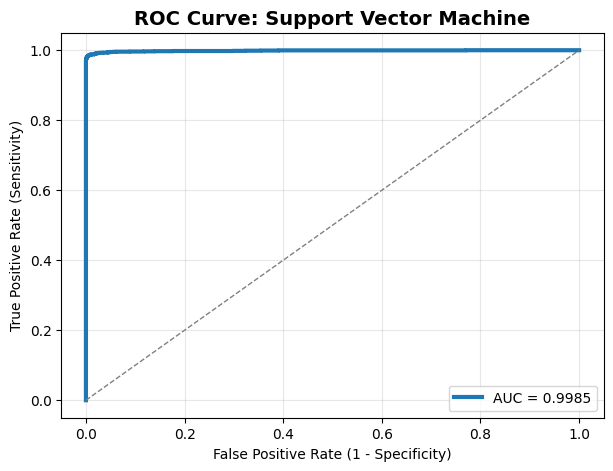

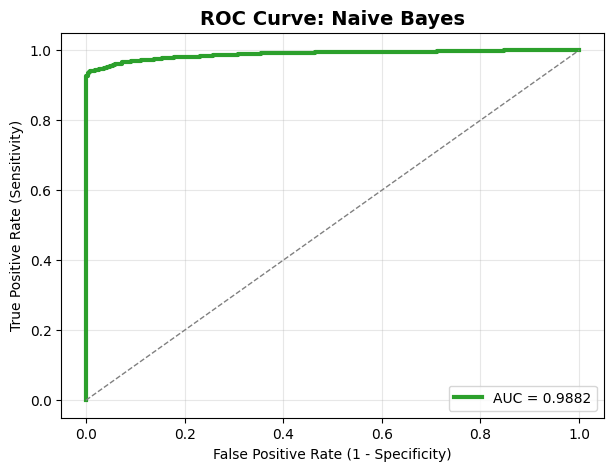

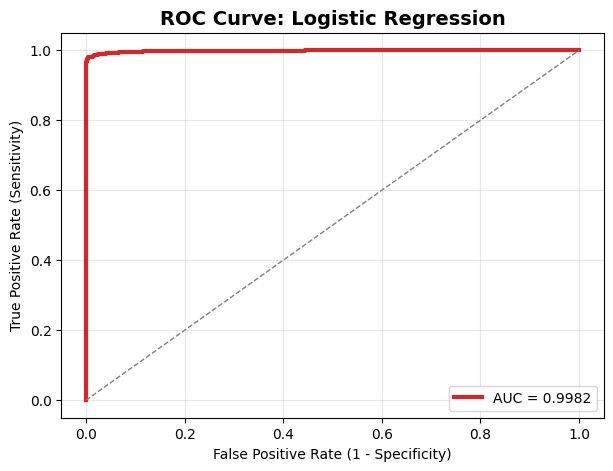

In [24]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Load the model
stacking_model = joblib.load('job_fraud_stacking_model.pkl')

# 2. Define the individual models
sub_models = {
    'Support Vector Machine': ('svm', '#1f77b4'), 
    'Naive Bayes': ('nb', '#2ca02c'),             
    'Logistic Regression': ('lr_base', '#d62728')  
}

# 3. Generate and show each plot ONE BY ONE
for label, (key, color) in sub_models.items():
    # Extract the internal 'employee' model
    model = stacking_model.named_estimators_[key]
    
    # Calculate probabilities and ROC values
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_val = roc_auc_score(y_test, y_probs)
    
    # Create a fresh figure for EVERY model
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color=color, lw=3, label=f'AUC = {auc_val:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    
    # Formatting the individual graph
    plt.title(f'ROC Curve: {label}', fontsize=14, fontweight='bold')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # Important: Save the image automatically if you want
    # plt.savefig(f"{key}_roc_plot.png") 
    
    plt.show() # This ensures the plots don't overlap

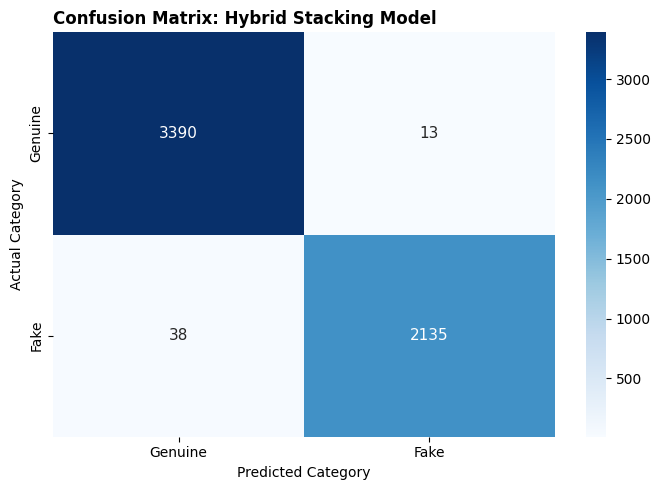


           FINAL HYBRID SYSTEM PERFORMANCE REPORT
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      3403
        Fake       0.99      0.98      0.99      2173

    accuracy                           0.99      5576
   macro avg       0.99      0.99      0.99      5576
weighted avg       0.99      0.99      0.99      5576



In [33]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load the model
stacking_model = joblib.load('job_fraud_stacking_model.pkl')

# 2. Get the Final Predictions
y_pred_final = stacking_model.predict(X_test)

# 3. Create the Visualization (Heatmap)
plt.figure(figsize=(7, 5))
cm_final = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm_final, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Genuine', 'Fake'], # Updated Labels
            yticklabels=['Genuine', 'Fake'], # Updated Labels
            annot_kws={"size": 11})

plt.title('Confusion Matrix: Hybrid Stacking Model', fontsize=12, fontweight='bold', loc='left')
plt.xlabel('Predicted Category', fontsize=10) # Using Category instead of Label
plt.ylabel('Actual Category', fontsize=10)    # Using Category instead of Label
plt.tight_layout()
plt.show()

# 4. Print the Performance Report
print("\n" + "="*60)
print("           FINAL HYBRID SYSTEM PERFORMANCE REPORT")
print("="*60)
# Update target_names here for the text report
report = classification_report(y_test, y_pred_final, target_names=['Genuine', 'Fake'])
print(report)
print("="*60)

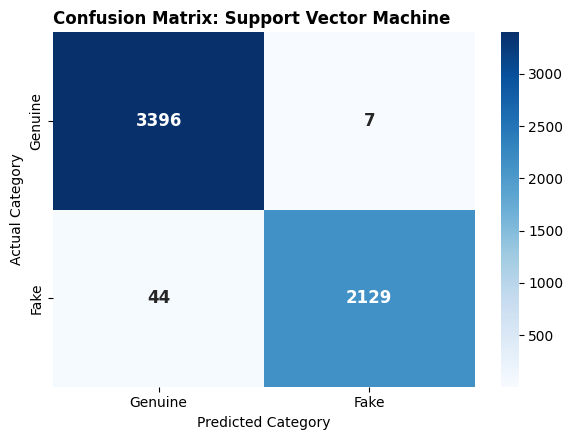


 PERFORMANCE ANALYSIS: SUPPORT VECTOR MACHINE
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      3403
        Fake       1.00      0.98      0.99      2173

    accuracy                           0.99      5576
   macro avg       0.99      0.99      0.99      5576
weighted avg       0.99      0.99      0.99      5576





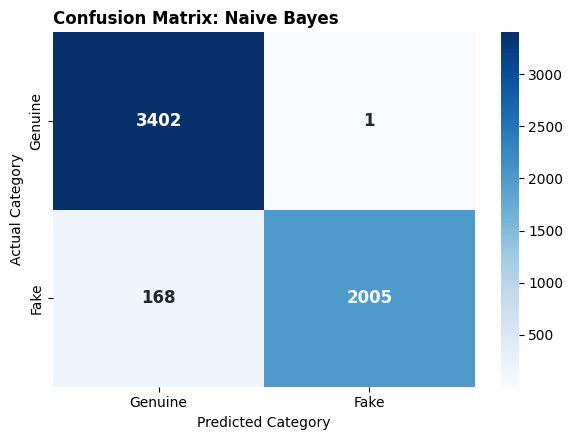


 PERFORMANCE ANALYSIS: NAIVE BAYES
              precision    recall  f1-score   support

     Genuine       0.95      1.00      0.98      3403
        Fake       1.00      0.92      0.96      2173

    accuracy                           0.97      5576
   macro avg       0.98      0.96      0.97      5576
weighted avg       0.97      0.97      0.97      5576





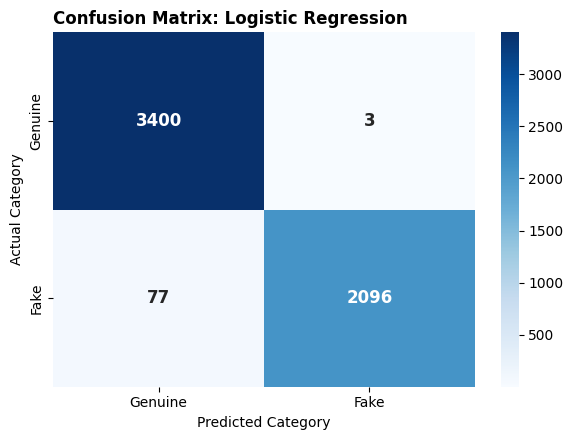


 PERFORMANCE ANALYSIS: LOGISTIC REGRESSION
              precision    recall  f1-score   support

     Genuine       0.98      1.00      0.99      3403
        Fake       1.00      0.96      0.98      2173

    accuracy                           0.99      5576
   macro avg       0.99      0.98      0.98      5576
weighted avg       0.99      0.99      0.99      5576





In [34]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Load the model
stacking_model = joblib.load('job_fraud_stacking_model.pkl')

# 2. Define the sub-models (All set to 'Blues')
sub_models = {
    'Support Vector Machine': 'svm', 
    'Naive Bayes': 'nb',             
    'Logistic Regression': 'lr_base'  
}

# 3. Generate individual Matrix + Performance Table
for label, key in sub_models.items():
    # Extract the internal model
    model = stacking_model.named_estimators_[key]
    
    # Get predictions for the test set
    y_pred = model.predict(X_test)
    
    # --- PART A: BLUE CONFUSION MATRIX ---
    plt.figure(figsize=(6, 4.5))
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, 
                annot=True, 
                fmt='d', 
                cmap='Blues', # <--- Standardized to Blues
                xticklabels=['Genuine', 'Fake'], 
                yticklabels=['Genuine', 'Fake'],
                annot_kws={"size": 12, "weight": "bold"})
    
    plt.title(f'Confusion Matrix: {label}', fontsize=12, fontweight='bold', loc='left')
    plt.xlabel('Predicted Category', fontsize=10)
    plt.ylabel('Actual Category', fontsize=10)
    
    # Clean up the plot edges to match your screenshot style
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

    # --- PART B: PERFORMANCE TABLE ---
    print("\n" + "="*65)
    print(f" PERFORMANCE ANALYSIS: {label.upper()}")
    print("="*65)
    # This generates Precision, Recall, F1, and Accuracy
    report = classification_report(y_test, y_pred, target_names=['Genuine', 'Fake'])
    print(report)
    print("="*65 + "\n\n")

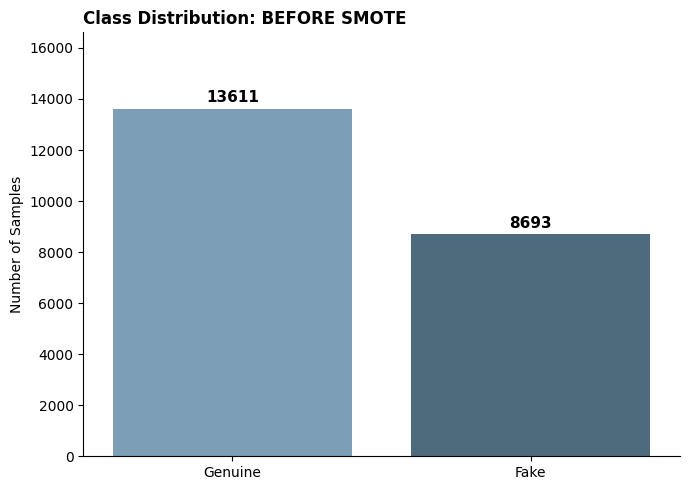

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Automatically detect counts from your original y_train_raw
counts_before = Counter(y_train_raw)
data_before = {'Genuine': counts_before[0], 'Fake': counts_before[1]}

# 2. Plotting Setup
plt.figure(figsize=(7, 5))
colors = ["#72A0C1", "#466D85"]

# Fixed syntax: added hue=x and legend=False to remove the warning
ax1 = sns.barplot(x=list(data_before.keys()), 
                 y=list(data_before.values()), 
                 hue=list(data_before.keys()), 
                 palette=colors, 
                 legend=False)

# 3. Formatting
plt.title('Class Distribution: BEFORE SMOTE', fontsize=12, fontweight='bold', loc='left')
plt.ylabel('Number of Samples')
plt.ylim(0, max(data_before.values()) + 3000)

# 4. Auto-annotate bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 8), 
                textcoords='offset points')

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

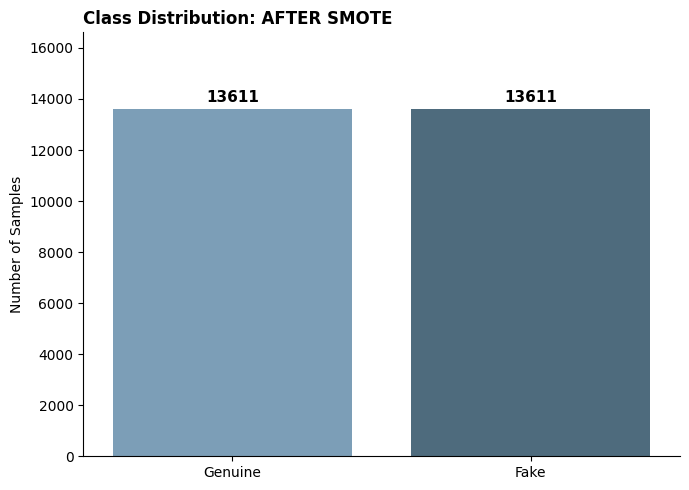

In [50]:
# 1. Automatically detect counts from your resampled y_train
counts_after = Counter(y_train) 
data_after = {'Genuine': counts_after[0], 'Fake': counts_after[1]}

# 2. Plotting Setup
plt.figure(figsize=(7, 5))

# Fixed syntax: added hue=x and legend=False
ax2 = sns.barplot(x=list(data_after.keys()), 
                 y=list(data_after.values()), 
                 hue=list(data_after.keys()), 
                 palette=colors, 
                 legend=False)

# 3. Formatting
plt.title('Class Distribution: AFTER SMOTE', fontsize=12, fontweight='bold', loc='left')
plt.ylabel('Number of Samples')
plt.ylim(0, max(data_after.values()) + 3000)

# 4. Auto-annotate bars
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 8), 
                textcoords='offset points')

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()